# Calculus and the Chain Rule for Deep Learning

**Why this notebook exists:** Backpropagation is nothing more than the chain rule applied repeatedly across a computation graph. If you understand the chain rule deeply — in scalar, vector, and matrix form — you can derive the gradient of any neural network layer from scratch.

**What you will be able to do after this notebook:**
- Compute derivatives and partial derivatives by hand
- Apply the chain rule through any composition of functions
- Understand exactly what `loss.backward()` computes in PyTorch
- Derive gradients for the linear layer, sigmoid, softmax, and cross-entropy
- Verify gradients using numerical differentiation (finite differences)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/himanshu231204/dl-mastery/blob/main/00_math/calculus_chain_rule.ipynb)

---

## Table of Contents
1. [Derivatives — the Slope of a Function](#1-derivatives)
2. [Partial Derivatives and Gradients](#2-partial-derivatives-and-gradients)
3. [The Chain Rule — scalar form](#3-the-chain-rule-scalar)
4. [Computational Graphs — how PyTorch sees your code](#4-computational-graphs)
5. [The Chain Rule — vector and matrix form](#5-chain-rule-vector-matrix)
6. [Numerical Gradient Checking](#6-numerical-gradient-checking)
7. [Deriving Gradients for Common DL Operations](#7-gradients-for-dl-operations)
8. [Automatic Differentiation — how autograd works](#8-automatic-differentiation)
9. [Visual Intuition](#9-visual-intuition)
10. [Exercises](#10-exercises)


## Setup

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)
np.set_printoptions(precision=6, suppress=True)

print('NumPy:', np.__version__)


NumPy: 2.0.2


## 1. Derivatives — the Slope of a Function

The derivative of $f(x)$ at point $x$ is the instantaneous rate of change — the slope of the tangent line:

$$f'(x) = \frac{df}{dx} = \lim_{h \to 0} \frac{f(x+h) - f(x)}{h}$$

**Interpretation:** If $f'(x) > 0$, increasing $x$ increases $f$. If $f'(x) < 0$, increasing $x$ decreases $f$. If $f'(x) = 0$, we are at a critical point (minimum, maximum, or saddle).

**In DL:** The derivative of the loss $L$ with respect to weight $w$ tells us:
> *In which direction should we change $w$ to decrease $L$ the most?*

We move in the **negative gradient direction**: $w \leftarrow w - \alpha \cdot \frac{dL}{dw}$

### Essential Derivative Rules

| Rule | Formula | DL example |
|---|---|---|
| Power | $\frac{d}{dx} x^n = n x^{n-1}$ | MSE loss |
| Exponential | $\frac{d}{dx} e^x = e^x$ | Softmax, sigmoid |
| Logarithm | $\frac{d}{dx} \ln x = \frac{1}{x}$ | Cross-entropy loss |
| Chain rule | $\frac{d}{dx} f(g(x)) = f'(g(x)) \cdot g'(x)$ | Backpropagation |
| Product | $\frac{d}{dx} f(x)g(x) = f'g + fg'$ | LSTM gate derivatives |

### Key Derivatives in DL

$$\frac{d}{dz} \sigma(z) = \sigma(z)(1 - \sigma(z)) \qquad \text{(sigmoid — elegant!)}$$

$$\frac{d}{dz} \tanh(z) = 1 - \tanh^2(z)$$

$$\frac{d}{dz} \text{ReLU}(z) = \begin{cases} 1 & z > 0 \\ 0 & z < 0 \end{cases}$$

$$\frac{d}{dw} \frac{1}{2}(y - wx)^2 = -(y - wx) \cdot x \qquad \text{(MSE gradient)}$$


In [29]:
# Numerical approximation of derivative — the definition
def numerical_derivative(f, x, h=1e-5):
    return (f(x + h) - f(x - h)) / (2 * h)   # central difference (more accurate)

# Test on several functions
functions = [
    ('f(x) = x^3',       lambda x: x**3,          lambda x: 3*x**2),
    ('f(x) = exp(x)',     lambda x: np.exp(x),     lambda x: np.exp(x)),
    ('f(x) = log(x)',     lambda x: np.log(x),     lambda x: 1/x),
    ('f(x) = sigmoid(x)', lambda x: 1/(1+np.exp(-x)), lambda x: (1/(1+np.exp(-x)))*(1-(1/(1+np.exp(-x))))),
]

x = 2.0
print(f'Verifying derivatives at x = {x}\n')
print(f'{'Function':<20}  {'Numerical':>12}  {'Analytical':>12}  {'Match':>8}')
print('-' * 60)
for name, f, df in functions:
    num  = numerical_derivative(f, x)
    anal = df(x)
    print(f'{name:<20}  {num:12.6f}  {anal:12.6f}  {str(np.isclose(num, anal, rtol=1e-4)):>8}')


Verifying derivatives at x = 2.0

Function                 Numerical    Analytical     Match
------------------------------------------------------------
f(x) = x^3               12.000000     12.000000      True
f(x) = exp(x)             7.389056      7.389056      True
f(x) = log(x)             0.500000      0.500000      True
f(x) = sigmoid(x)         0.104994      0.104994      True


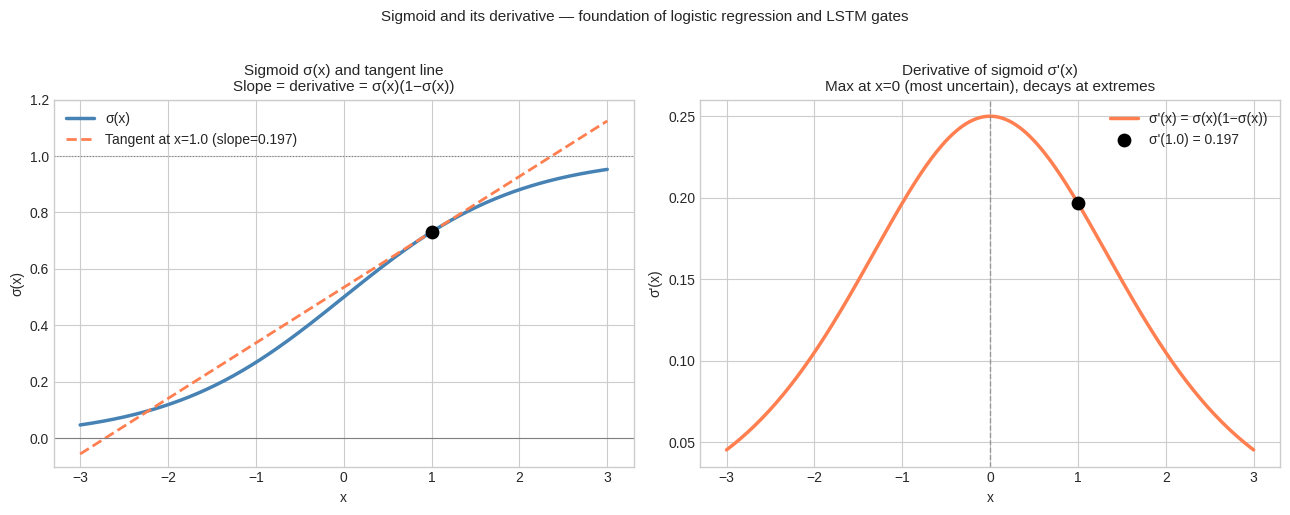

Key insight: σ(x)(1-σ(x)) ≤ 0.25 always.
Multiply 100 such values through a deep network -> gradient near zero -> vanishing gradient problem.


In [30]:
# Visualize: function, its derivative, and tangent line at a point
x = np.linspace(-3, 3, 300)
sigmoid   = 1 / (1 + np.exp(-x))
d_sigmoid = sigmoid * (1 - sigmoid)

x0 = 1.0
s0 = 1 / (1 + np.exp(-x0))
ds0 = s0 * (1 - s0)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Sigmoid and tangent line
tangent = s0 + ds0 * (x - x0)
axes[0].plot(x, sigmoid,            color='steelblue', linewidth=2.5, label='σ(x)')
axes[0].plot(x, tangent,            color='coral',     linewidth=2,   linestyle='--',
             label=f'Tangent at x={x0} (slope={ds0:.3f})')
axes[0].scatter([x0], [s0], color='black', s=80, zorder=5)
axes[0].axhline(0, color='gray', linewidth=0.8)
axes[0].axhline(1, color='gray', linewidth=0.8, linestyle=':')
axes[0].set_title('Sigmoid σ(x) and tangent line\nSlope = derivative = σ(x)(1−σ(x))', fontsize=11)
axes[0].set_xlabel('x'); axes[0].set_ylabel('σ(x)')
axes[0].legend(); axes[0].set_ylim(-0.1, 1.2)

# Derivative of sigmoid
axes[1].plot(x, d_sigmoid, color='coral', linewidth=2.5, label="σ'(x) = σ(x)(1−σ(x))")
axes[1].axvline(0, color='gray', linewidth=1, linestyle='--', alpha=0.7)
axes[1].scatter([x0], [ds0], color='black', s=80, zorder=5,
                label=f"σ'({x0}) = {ds0:.3f}")
axes[1].set_title("Derivative of sigmoid σ'(x)\nMax at x=0 (most uncertain), decays at extremes", fontsize=11)
axes[1].set_xlabel('x'); axes[1].set_ylabel("σ'(x)")
axes[1].legend()

plt.suptitle('Sigmoid and its derivative — foundation of logistic regression and LSTM gates',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

print('Key insight: σ(x)(1-σ(x)) ≤ 0.25 always.')
print('Multiply 100 such values through a deep network -> gradient near zero -> vanishing gradient problem.')


## 2. Partial Derivatives and Gradients

When a function takes multiple inputs, the **partial derivative** $\frac{\partial f}{\partial x_i}$ measures the rate of change with respect to $x_i$ while holding all other inputs constant.

The **gradient** is the vector of all partial derivatives:

$$\nabla f(\mathbf{x}) = \left[\frac{\partial f}{\partial x_1}, \frac{\partial f}{\partial x_2}, \dots, \frac{\partial f}{\partial x_n}\right]^T$$

**Critical property:** The gradient $\nabla f(\mathbf{x})$ always points in the direction of **steepest ascent**. The negative gradient $-\nabla f(\mathbf{x})$ points in the direction of steepest descent — this is exactly where gradient descent steps.

### MSE Loss Gradient — worked example

$$L = \frac{1}{m} \sum_{i=1}^m (y_i - \hat{y}_i)^2 \quad\text{where}\quad \hat{y}_i = w_1 x_{i1} + w_2 x_{i2} + b$$

$$\frac{\partial L}{\partial w_1} = \frac{-2}{m} \sum_{i=1}^m (y_i - \hat{y}_i) x_{i1}$$

$$\frac{\partial L}{\partial w_2} = \frac{-2}{m} \sum_{i=1}^m (y_i - \hat{y}_i) x_{i2}$$

$$\frac{\partial L}{\partial b} = \frac{-2}{m} \sum_{i=1}^m (y_i - \hat{y}_i)$$

In matrix form (for a batch):

$$\nabla_W L = \frac{-2}{m} X^T (y - \hat{y}) \qquad \nabla_b L = \frac{-2}{m} \sum (y - \hat{y})$$


/tmp/ipykernel_6161/2838807427.py:60: UserWarning: Glyph 8711 (\N{NABLA}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8711 (\N{NABLA}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


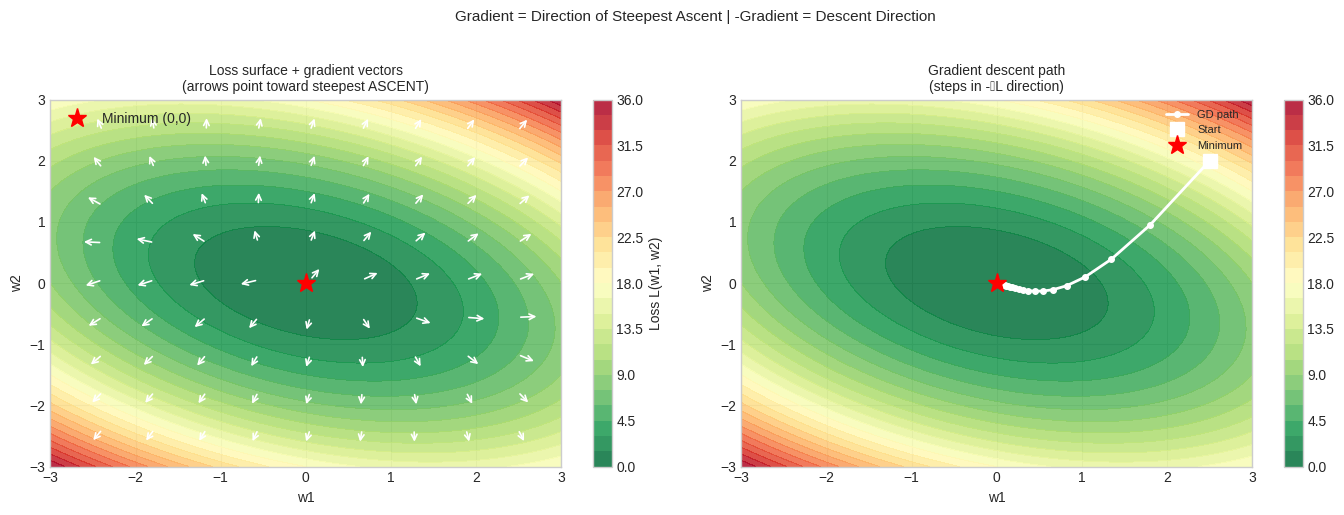

In [31]:
# Visualize the gradient as direction of steepest ascent
def f_2d(x1, x2):
    return x1**2 + 2*x2**2 + x1*x2   # a bowl-shaped function

def grad_f_2d(x1, x2):
    df_dx1 = 2*x1 + x2
    df_dx2 = 4*x2 + x1
    return np.array([df_dx1, df_dx2])

x1_range = np.linspace(-3, 3, 60)
x2_range = np.linspace(-3, 3, 60)
X1, X2   = np.meshgrid(x1_range, x2_range)
Z        = f_2d(X1, X2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss surface contour
cp = axes[0].contourf(X1, X2, Z, levels=25, cmap='RdYlGn_r', alpha=0.85)
plt.colorbar(cp, ax=axes[0], label='Loss L(w1, w2)')

# Draw gradient vectors (arrows)
step = 6
for i in range(0, 60, step):
    for j in range(0, 60, step):
        x1v, x2v = X1[i, j], X2[i, j]
        g = grad_f_2d(x1v, x2v)
        g_norm = np.linalg.norm(g)
        if g_norm > 0.1:
            scale = 0.25 / g_norm
            axes[0].annotate('', xy=(x1v + g[0]*scale, x2v + g[1]*scale),
                             xytext=(x1v, x2v),
                             arrowprops=dict(arrowstyle='->', color='white', lw=1.2))

axes[0].plot(0, 0, 'r*', markersize=14, zorder=5, label='Minimum (0,0)')
axes[0].set_title('Loss surface + gradient vectors\n(arrows point toward steepest ASCENT)', fontsize=10)
axes[0].set_xlabel('w1'); axes[0].set_ylabel('w2')
axes[0].legend()

# Gradient descent path
w = np.array([2.5, 2.0])   # start far from minimum
lr = 0.1
path = [w.copy()]
for _ in range(30):
    g = grad_f_2d(w[0], w[1])
    w = w - lr * g          # negative gradient direction
    path.append(w.copy())
path = np.array(path)

cp2 = axes[1].contourf(X1, X2, Z, levels=25, cmap='RdYlGn_r', alpha=0.85)
plt.colorbar(cp2, ax=axes[1])
axes[1].plot(path[:, 0], path[:, 1], 'w-o', markersize=4, linewidth=2, label='GD path', zorder=5)
axes[1].plot(path[0, 0], path[0, 1], 'ws', markersize=10, label='Start', zorder=6)
axes[1].plot(0, 0, 'r*', markersize=14, label='Minimum', zorder=6)
axes[1].set_title('Gradient descent path\n(steps in -∇L direction)', fontsize=10)
axes[1].set_xlabel('w1'); axes[1].set_ylabel('w2')
axes[1].legend(fontsize=8)

plt.suptitle('Gradient = Direction of Steepest Ascent | -Gradient = Descent Direction',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()


## 3. The Chain Rule — Scalar Form

The chain rule computes the derivative of a **composition** of functions.

For $L = f(g(x))$:

$$\frac{dL}{dx} = \frac{dL}{dg} \cdot \frac{dg}{dx} = f'(g(x)) \cdot g'(x)$$

For a longer chain $L = f_4(f_3(f_2(f_1(x))))$:

$$\frac{dL}{dx} = \frac{\partial f_4}{\partial f_3} \cdot \frac{\partial f_3}{\partial f_2} \cdot \frac{\partial f_2}{\partial f_1} \cdot \frac{\partial f_1}{\partial x}$$

**This is backpropagation.** A neural network is a long chain of functions. Backprop starts from $\frac{dL}{dL} = 1$ and multiplies backward through each layer.

### Worked Example — one neuron with sigmoid

Forward pass:
$$z = wx + b \qquad \hat{y} = \sigma(z) \qquad L = \frac{1}{2}(y - \hat{y})^2$$

Backward pass (chain rule applied right to left):

$$\frac{\partial L}{\partial \hat{y}} = -(y - \hat{y})$$

$$\frac{\partial \hat{y}}{\partial z} = \sigma(z)(1 - \sigma(z)) = \hat{y}(1 - \hat{y})$$

$$\frac{\partial z}{\partial w} = x \qquad \frac{\partial z}{\partial b} = 1$$

$$\boxed{\frac{\partial L}{\partial w} = \frac{\partial L}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial z} \cdot \frac{\partial z}{\partial w} = -(y - \hat{y}) \cdot \hat{y}(1-\hat{y}) \cdot x}$$

Notice: the gradient flows **backward** through $\frac{\partial z}{\partial w}$, then through the activation, then through the loss. This is exactly what PyTorch computes when you call `loss.backward()`.


In [32]:
# Manual chain rule — one neuron with sigmoid
def sigmoid(z): return 1 / (1 + np.exp(-z))

# Single training example
x = 2.0
y = 1.0    # true label
w = 0.5    # weight
b = -0.3   # bias

# ── Forward pass ─────────────────────────────────────────────────────────
z      = w * x + b          # linear combination
y_hat  = sigmoid(z)         # sigmoid activation
loss   = 0.5 * (y - y_hat)**2  # MSE loss

print('=== FORWARD PASS ===')
print(f'  z = w*x + b = {w}*{x} + {b} = {z}')
print(f'  ŷ = σ(z)    = σ({z:.4f}) = {y_hat:.6f}')
print(f'  L = ½(y-ŷ)² = ½({y}-{y_hat:.4f})² = {loss:.8f}')

# ── Backward pass (chain rule) ────────────────────────────────────────────
dL_dyhat = -(y - y_hat)                  # ∂L/∂ŷ
dyhat_dz = y_hat * (1 - y_hat)           # ∂ŷ/∂z = σ'(z)
dz_dw    = x                             # ∂z/∂w
dz_db    = 1.0                           # ∂z/∂b

# Chain rule
dL_dz = dL_dyhat * dyhat_dz              # ∂L/∂z (the 'delta' or 'error signal')
dL_dw = dL_dz * dz_dw                   # ∂L/∂w
dL_db = dL_dz * dz_db                   # ∂L/∂b

print('\n=== BACKWARD PASS (Chain Rule) ===')
print(f'  ∂L/∂ŷ  = -(y-ŷ)         = {dL_dyhat:.6f}')
print(f'  ∂ŷ/∂z  = ŷ(1-ŷ)         = {dyhat_dz:.6f}')
print(f'  ∂z/∂w  = x               = {dz_dw}')
print(f'  ∂z/∂b  = 1               = {dz_db}')
print(f'  ∂L/∂z  = ∂L/∂ŷ × ∂ŷ/∂z = {dL_dz:.6f}')
print(f'  ∂L/∂w  = ∂L/∂z × ∂z/∂w = {dL_dw:.6f}  <- weight gradient')
print(f'  ∂L/∂b  = ∂L/∂z × ∂z/∂b = {dL_db:.6f}  <- bias gradient')


=== FORWARD PASS ===
  z = w*x + b = 0.5*2.0 + -0.3 = 0.7
  ŷ = σ(z)    = σ(0.7000) = 0.668188
  L = ½(y-ŷ)² = ½(1.0-0.6682)² = 0.05504968

=== BACKWARD PASS (Chain Rule) ===
  ∂L/∂ŷ  = -(y-ŷ)         = -0.331812
  ∂ŷ/∂z  = ŷ(1-ŷ)         = 0.221713
  ∂z/∂w  = x               = 2.0
  ∂z/∂b  = 1               = 1.0
  ∂L/∂z  = ∂L/∂ŷ × ∂ŷ/∂z = -0.073567
  ∂L/∂w  = ∂L/∂z × ∂z/∂w = -0.147134  <- weight gradient
  ∂L/∂b  = ∂L/∂z × ∂z/∂b = -0.073567  <- bias gradient


In [33]:
# Verify with numerical gradients
def compute_loss(w, b, x, y):
    z     = w * x + b
    y_hat = sigmoid(z)
    return 0.5 * (y - y_hat)**2

h = 1e-5
dL_dw_num = (compute_loss(w+h, b, x, y) - compute_loss(w-h, b, x, y)) / (2*h)
dL_db_num = (compute_loss(w, b+h, x, y) - compute_loss(w, b-h, x, y)) / (2*h)

print('Gradient verification:')
print(f'  dL/dw: analytical={dL_dw:.8f}  numerical={dL_dw_num:.8f}  match={np.isclose(dL_dw, dL_dw_num)}')
print(f'  dL/db: analytical={dL_db:.8f}  numerical={dL_db_num:.8f}  match={np.isclose(dL_db, dL_db_num)}')


Gradient verification:
  dL/dw: analytical=-0.14713408  numerical=-0.14713408  match=True
  dL/db: analytical=-0.07356704  numerical=-0.07356704  match=True


## 4. Computational Graphs — How PyTorch Sees Your Code

PyTorch builds a **computational graph** dynamically as your code runs. Every operation (`+`, `*`, `@`, `sigmoid`, etc.) creates a node in this graph. Each node stores:
1. The **forward value** (the output of the operation)
2. The **backward function** (how to compute the gradient)

When you call `loss.backward()`, PyTorch traverses this graph **right to left** (from loss back to inputs), applying the chain rule at each node.

### Example graph for $L = \frac{1}{2}(y - \sigma(wx+b))^2$

```
x ─────┐
       ├──→ [multiply] ──→ z = wx+b ──→ [sigmoid] ──→ ŷ ──→ [subtract] ──→ e ──→ [square] ──→ L
w ─────┘                                                       ↑
b ────────────────────────────────────────────────────────→ [add]
y ────────────────────────────────────────────────────────────────────────────────→
```

Backpropagation visits each node right to left:
1. At `[square]`: $\frac{\partial L}{\partial e} = e$
2. At `[subtract]`: $\frac{\partial e}{\partial \hat{y}} = -1$
3. At `[sigmoid]`: $\frac{\partial \hat{y}}{\partial z} = \hat{y}(1 - \hat{y})$
4. At `[multiply]`: $\frac{\partial z}{\partial w} = x$, $\frac{\partial z}{\partial x} = w$

**Why dynamic graphs?** Unlike TensorFlow 1.x (static graphs), PyTorch builds the graph at runtime. This means Python control flow (`if`, `for`, `while`) works naturally — the graph changes shape depending on the input. This is essential for RNNs with variable-length sequences.


In [53]:
# Simulate a minimal computational graph with manual backward functions
class Value:
    """
    A scalar value that tracks its gradient.
    Inspired by Andrej Karpathy's micrograd.
    """
    def __init__(self, data, _children=(), op='', label=''):
        self.data     = float(data)
        self.grad     = 0.0          # gradient accumulates here
        self._backward = lambda: None  # backward function for this node
        self._prev    = set(_children)
        self.op       = op
        self.label    = label

    def __repr__(self):
        return f'Value(data={self.data:.4f}, grad={self.grad:.4f}, label={self.label})'

    def __add__(self, other):
        other  = other if isinstance(other, Value) else Value(other)
        out    = Value(self.data + other.data, (self, other), '+')
        def _backward():
            # dL/d(self) += dL/d(out) * d(out)/d(self) = dL/d(out) * 1
            self.grad  += out.grad
            other.grad += out.grad
        out._backward = _backward
        return out

    def __mul__(self, other):
        other  = other if isinstance(other, Value) else Value(other)
        out    = Value(self.data * other.data, (self, other), '*')
        def _backward():
            # d(a*b)/da = b,  d(a*b)/db = a
            self.grad  += other.data * out.grad
            other.grad += self.data  * out.grad
        out._backward = _backward
        return out

    def __pow__(self, exp):
        assert isinstance(exp, (int, float))
        out = Value(self.data**exp, (self,), f'**{exp}')
        def _backward():
            self.grad += exp * (self.data**(exp-1)) * out.grad
        out._backward = _backward
        return out

    def sigmoid(self):
        s   = 1 / (1 + np.exp(-self.data))
        out = Value(s, (self,), 'sigmoid')
        def _backward():
            # d(sigmoid)/dz = s*(1-s)
            self.grad += s * (1 - s) * out.grad
        out._backward = _backward
        return out

    def tanh(self):
        t   = np.tanh(self.data)
        out = Value(t, (self,), 'tanh')
        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        return out

    def backward(self):
        # Topological sort then call _backward in reverse
        topo, visited = [], set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        self.grad = 1.0   # dL/dL = 1
        for v in reversed(topo):
            v._backward()

# Build the graph: L = 0.5 * (y - sigmoid(w*x + b))^2
x_v = Value(2.0,  label='x')
w_v = Value(0.5,  label='w')
b_v = Value(-0.3, label='b')
y_v = Value(1.0,  label='y')

z_v    = w_v * x_v + b_v
yhat_v = z_v.sigmoid()
e_v    = y_v + (yhat_v * Value(-1))
L_v    = e_v * e_v * Value(0.5)

print('=== Forward pass values ===')
print(f'z    = {z_v.data:.6f}')
print(f'ŷ    = {yhat_v.data:.6f}')
print(f'L    = {L_v.data:.8f}')

L_v.backward()

print('\n=== Backward pass (autograd) ===')
print(f'dL/dw = {w_v.grad:.8f}  (should match our manual: {dL_dw:.8f})')
print(f'dL/db = {b_v.grad:.8f}  (should match our manual: {dL_db:.8f})')
print(f'Match w: {np.isclose(w_v.grad, dL_dw)}')
print(f'Match b: {np.isclose(b_v.grad, dL_db)}')


=== Forward pass values ===
z    = 0.700000
ŷ    = 0.668188
L    = 0.05504968

=== Backward pass (autograd) ===
dL/dw = -0.14713408  (should match our manual: -0.14713408)
dL/db = -0.07356704  (should match our manual: -0.07356704)
Match w: True
Match b: True


## 5. The Chain Rule — Vector and Matrix Form

In DL, inputs and outputs are vectors and matrices, not scalars. The chain rule generalizes through the **Jacobian matrix**.

### Jacobian Matrix

For a vector function $\mathbf{f}: \mathbb{R}^n \to \mathbb{R}^m$, the Jacobian is the matrix of all partial derivatives:

$$J = \frac{\partial \mathbf{f}}{\partial \mathbf{x}} \in \mathbb{R}^{m \times n} \qquad J_{ij} = \frac{\partial f_i}{\partial x_j}$$

The vector chain rule:

$$\frac{\partial L}{\partial \mathbf{x}} = J^T \frac{\partial L}{\partial \mathbf{f}}$$

### Gradient of a Linear Layer

For $\mathbf{y} = W\mathbf{x} + \mathbf{b}$, given upstream gradient $\frac{\partial L}{\partial \mathbf{y}}$:

$$\frac{\partial L}{\partial W} = \frac{\partial L}{\partial \mathbf{y}} \mathbf{x}^T \qquad \frac{\partial L}{\partial \mathbf{b}} = \frac{\partial L}{\partial \mathbf{y}} \qquad \frac{\partial L}{\partial \mathbf{x}} = W^T \frac{\partial L}{\partial \mathbf{y}}$$

**Derivation of $\frac{\partial L}{\partial W}$:** Since $y_i = \sum_j W_{ij} x_j + b_i$, we have $\frac{\partial y_i}{\partial W_{ij}} = x_j$. By chain rule: $\frac{\partial L}{\partial W_{ij}} = \frac{\partial L}{\partial y_i} x_j$. In matrix form: $\frac{\partial L}{\partial W} = \frac{\partial L}{\partial \mathbf{y}} \otimes \mathbf{x}^T$.

**For a batch** $Y = XW^T + b$ where $X \in \mathbb{R}^{m \times n_{in}}$:

$$\frac{\partial L}{\partial W} = \left(\frac{\partial L}{\partial Y}\right)^T X \qquad \frac{\partial L}{\partial X} = \frac{\partial L}{\partial Y} W$$


In [35]:
# Vector chain rule — gradient through a linear layer (batch version)
np.random.seed(0)

batch, in_dim, out_dim = 4, 3, 2
X = np.random.randn(batch, in_dim)
W = np.random.randn(out_dim, in_dim)
b = np.random.randn(out_dim)

# Forward: Y = X W^T + b
Y = X @ W.T + b            # (4, 2)

# Suppose downstream gradient dL/dY (given from later layers)
dL_dY = np.ones((batch, out_dim)) / (batch * out_dim)  # shape (4, 2)

# Backward: chain rule
# dL/dW = (dL/dY)^T @ X        shape: (2,4) @ (4,3) = (2,3) = same as W
# dL/db = sum(dL/dY, axis=0)   shape: (2,) = same as b
# dL/dX = dL/dY @ W            shape: (4,2) @ (2,3) = (4,3) = same as X

dL_dW = dL_dY.T @ X        # (out, in) — same shape as W
dL_db = dL_dY.sum(axis=0)  # (out,) — same shape as b
dL_dX = dL_dY @ W          # (batch, in) — same shape as X

print('Shapes — always verify these match the parameter shapes!')
print(f'  X:     {X.shape}     W:     {W.shape}  b: {b.shape}')
print(f'  Y:     {Y.shape}')
print(f'  dL/dY: {dL_dY.shape}')
print(f'  dL/dW: {dL_dW.shape}  <- matches W shape ✓')
print(f'  dL/db: {dL_db.shape}      <- matches b shape ✓')
print(f'  dL/dX: {dL_dX.shape}     <- matches X shape ✓')


Shapes — always verify these match the parameter shapes!
  X:     (4, 3)     W:     (2, 3)  b: (2,)
  Y:     (4, 2)
  dL/dY: (4, 2)
  dL/dW: (2, 3)  <- matches W shape ✓
  dL/db: (2,)      <- matches b shape ✓
  dL/dX: (4, 3)     <- matches X shape ✓


In [36]:
# Verify all gradients numerically
def forward_loss(X, W, b):
    Y = X @ W.T + b
    return Y.mean()   # simple scalar loss

h = 1e-5
print('Numerical gradient verification for dL/dW:')
print(f'{'[i,j]':<10}  {'Analytical':>12}  {'Numerical':>12}  {'Match':>8}')

for i in range(out_dim):
    for j in range(in_dim):
        W_plus  = W.copy(); W_plus[i,j]  += h
        W_minus = W.copy(); W_minus[i,j] -= h
        grad_num = (forward_loss(X, W_plus, b) - forward_loss(X, W_minus, b)) / (2*h)
        print(f'[{i},{j}]       {dL_dW[i,j]:12.6f}  {grad_num:12.6f}  {str(np.isclose(dL_dW[i,j], grad_num, rtol=1e-4)):>8}')


Numerical gradient verification for dL/dW:
[i,j]         Analytical     Numerical     Match
[0,0]           0.670704      0.670704      True
[0,1]           0.282550      0.282550      True
[0,2]           0.169064      0.169064      True
[1,0]           0.670704      0.670704      True
[1,1]           0.282550      0.282550      True
[1,2]           0.169064      0.169064      True


## 6. Numerical Gradient Checking

**Gradient checking** is the most important debugging tool in DL. Before trusting your backpropagation implementation, always verify it against numerical gradients using finite differences.

**Central difference formula** (more accurate than one-sided):

$$\frac{\partial L}{\partial \theta_i} \approx \frac{L(\theta + h\mathbf{e}_i) - L(\theta - h\mathbf{e}_i)}{2h}$$

where $\mathbf{e}_i$ is the unit vector in direction $i$ and $h \approx 10^{-5}$.

**Relative error metric:**

$$\text{relative error} = \frac{\|\nabla_{\text{analytical}} - \nabla_{\text{numerical}}\|}{\|\nabla_{\text{analytical}}\| + \|\nabla_{\text{numerical}}\|}$$

- $< 10^{-7}$: excellent — your gradients are correct
- $10^{-5}$ to $10^{-7}$: acceptable
- $> 10^{-3}$: bug in your backward pass

**When to use it:** After implementing any new layer or loss function. PyTorch has `torch.autograd.gradcheck()` which does this automatically.


In [37]:
def gradient_check(loss_fn, params, analytical_grads, h=1e-5):
    """
    Checks analytical gradients against numerical gradients.
    params: list of parameter arrays
    analytical_grads: list of gradient arrays (same shape as params)
    """
    results = []
    for idx, (param, ag) in enumerate(zip(params, analytical_grads)):
        num_grad = np.zeros_like(param)
        it = np.nditer(param, flags=['multi_index'])
        while not it.finished:
            ix = it.multi_index
            orig = param[ix]
            param[ix] = orig + h;  loss_plus  = loss_fn()
            param[ix] = orig - h;  loss_minus = loss_fn()
            param[ix] = orig
            num_grad[ix] = (loss_plus - loss_minus) / (2*h)
            it.iternext()

        # Relative error
        diff    = np.linalg.norm(ag - num_grad)
        denom   = np.linalg.norm(ag) + np.linalg.norm(num_grad) + 1e-12
        rel_err = diff / denom
        results.append({'param_idx': idx, 'rel_error': rel_err,
                        'passed': rel_err < 1e-5})
    return results

# Test on a 2-layer network
np.random.seed(1)
X_gc = np.random.randn(5, 4)
y_gc = np.random.randint(0, 3, 5)

W1 = np.random.randn(6, 4) * 0.1
b1 = np.zeros(6)
W2 = np.random.randn(3, 6) * 0.1
b2 = np.zeros(3)

def forward_and_backward():
    # Forward
    z1    = X_gc @ W1.T + b1
    a1    = np.maximum(0, z1)          # ReLU
    z2    = a1 @ W2.T + b2
    # Softmax + cross-entropy (stable)
    z2_s  = z2 - z2.max(axis=1, keepdims=True)
    exp_z = np.exp(z2_s)
    probs = exp_z / exp_z.sum(axis=1, keepdims=True)
    m     = len(y_gc)
    loss  = -np.log(probs[np.arange(m), y_gc] + 1e-12).mean()

    # Backward
    dz2   = probs.copy()
    dz2[np.arange(m), y_gc] -= 1
    dz2  /= m
    dW2   = dz2.T @ a1
    db2   = dz2.sum(axis=0)
    da1   = dz2 @ W2
    dz1   = da1 * (z1 > 0)
    dW1   = dz1.T @ X_gc
    db1   = dz1.sum(axis=0)
    return loss, [dW1, db1, dW2, db2]

loss_val, grads = forward_and_backward()

def loss_fn():
    z1    = X_gc @ W1.T + b1
    a1    = np.maximum(0, z1)
    z2    = a1 @ W2.T + b2
    z2_s  = z2 - z2.max(axis=1, keepdims=True)
    exp_z = np.exp(z2_s)
    probs = exp_z / exp_z.sum(axis=1, keepdims=True)
    return -np.log(probs[np.arange(len(y_gc)), y_gc]+1e-12).mean()

results = gradient_check(loss_fn, [W1, b1, W2, b2], grads)
print('Gradient Check Results:')
for r in results:
    param_name = ['W1','b1','W2','b2'][r['param_idx']]
    status = '✓ PASS' if r['passed'] else '✗ FAIL'
    print(f'  {param_name}: rel_error = {r["rel_error"]:.2e}  {status}')


Gradient Check Results:
  W1: rel_error = 1.64e-10  ✓ PASS
  b1: rel_error = 2.24e-10  ✓ PASS
  W2: rel_error = 1.26e-10  ✓ PASS
  b2: rel_error = 1.82e-11  ✓ PASS


## 7. Deriving Gradients for Common DL Operations

These are the building blocks of backpropagation. Every DL framework implements exactly these.


In [38]:
print('=== ReLU gradient ===')
print('Forward:  f(z) = max(0, z)')
print('Backward: df/dz = 1 if z > 0 else 0   (subgradient at z=0 is 0)')
print()

def relu_forward(z):
    return np.maximum(0, z)

def relu_backward(dL_da, z):
    # dL/dz = dL/da * da/dz = dL/da * (z > 0)
    return dL_da * (z > 0)

z_test  = np.array([-2.0, -0.5, 0.0, 0.5, 2.0])
a_test  = relu_forward(z_test)
dL_da   = np.ones_like(a_test)
dL_dz   = relu_backward(dL_da, z_test)

print(f'z:     {z_test}')
print(f'a=ReLU:{a_test}')
print(f'dL/dz: {dL_dz}   <- zero where z≤0 (dead neurons!)')


=== ReLU gradient ===
Forward:  f(z) = max(0, z)
Backward: df/dz = 1 if z > 0 else 0   (subgradient at z=0 is 0)

z:     [-2.  -0.5  0.   0.5  2. ]
a=ReLU:[0.  0.  0.  0.5 2. ]
dL/dz: [0. 0. 0. 1. 1.]   <- zero where z≤0 (dead neurons!)


In [39]:
print('=== Softmax + Cross-Entropy gradient (combined) ===')
print()
print('Forward:  p = softmax(z),  L = -log(p_y)  where y is the true class')
print('Backward: dL/dz_i = p_i - 1(i==y)   <- surprisingly clean!')
print()
print('Derivation:')
print('  dL/dp_y = -1/p_y                    (from cross-entropy)')
print('  dp_y/dz_i = p_y(1-p_y) if i==y      (from softmax diagonal)')
print('            = -p_y * p_i   if i≠y      (from softmax off-diagonal)')
print('  Chain rule: dL/dz_i = p_i - 1(i==y) <- combine and simplify')
print()

def softmax(z):
    z_stable = z - z.max(axis=-1, keepdims=True)  # stability: subtract max
    e = np.exp(z_stable)
    return e / e.sum(axis=-1, keepdims=True)

def softmax_ce_backward(probs, y_true):
    # Combined gradient: p_i - 1(i == y_true)
    grad = probs.copy()
    grad[np.arange(len(y_true)), y_true] -= 1
    return grad / len(y_true)   # average over batch

# Example: batch of 3, 4 classes
logits = np.array([[2.0, 1.0, 0.5, -1.0],
                   [0.1, 3.0, 0.2,  0.3],
                   [1.0, 1.0, 1.0,  1.0]])
y_true = np.array([0, 1, 2])   # true class labels

probs = softmax(logits)
loss  = -np.log(probs[np.arange(3), y_true]).mean()
grads = softmax_ce_backward(probs, y_true)

print(f'Logits:\n{logits}')
print(f'\nProbabilities (softmax):\n{probs.round(4)}')
print(f'\nLoss: {loss:.4f}')
print(f'\nGradient dL/dz:\n{grads.round(4)}')
print('\nInterpretation: gradient pushes logit of correct class down and others up')


=== Softmax + Cross-Entropy gradient (combined) ===

Forward:  p = softmax(z),  L = -log(p_y)  where y is the true class
Backward: dL/dz_i = p_i - 1(i==y)   <- surprisingly clean!

Derivation:
  dL/dp_y = -1/p_y                    (from cross-entropy)
  dp_y/dz_i = p_y(1-p_y) if i==y      (from softmax diagonal)
            = -p_y * p_i   if i≠y      (from softmax off-diagonal)
  Chain rule: dL/dz_i = p_i - 1(i==y) <- combine and simplify

Logits:
[[ 2.   1.   0.5 -1. ]
 [ 0.1  3.   0.2  0.3]
 [ 1.   1.   1.   1. ]]

Probabilities (softmax):
[[0.6095 0.2242 0.136  0.0303]
 [0.0465 0.8453 0.0514 0.0568]
 [0.25   0.25   0.25   0.25  ]]

Loss: 0.6832

Gradient dL/dz:
[[-0.1302  0.0747  0.0453  0.0101]
 [ 0.0155 -0.0516  0.0171  0.0189]
 [ 0.0833  0.0833 -0.25    0.0833]]

Interpretation: gradient pushes logit of correct class down and others up


In [40]:
print('=== Batch Normalization gradient ===')
print()
print('Forward:  x_hat = (x - μ) / √(σ² + ε),  y = γ*x_hat + β')
print()
print('Backward (simplified — see Ioffe & Szegedy 2015 for full derivation):')
print('  dL/dγ = Σ_i dL/dy_i * x_hat_i          <- scale gradient')
print('  dL/dβ = Σ_i dL/dy_i                     <- shift gradient')
print('  dL/dx is more complex — involves interactions through μ and σ')
print()

def batchnorm_forward(x, gamma, beta, eps=1e-5):
    mu    = x.mean(axis=0)                   # mean over batch
    var   = x.var(axis=0)                    # variance over batch
    x_hat = (x - mu) / np.sqrt(var + eps)   # normalize
    y     = gamma * x_hat + beta             # scale and shift
    cache = (x, x_hat, mu, var, gamma, eps)
    return y, cache

def batchnorm_backward(dL_dy, cache):
    x, x_hat, mu, var, gamma, eps = cache
    m     = x.shape[0]
    dL_dgamma = (dL_dy * x_hat).sum(axis=0)
    dL_dbeta  = dL_dy.sum(axis=0)
    # Gradient through x_hat
    dL_dxhat  = dL_dy * gamma
    dL_dvar   = (dL_dxhat * (x - mu) * (-0.5) * (var + eps)**(-1.5)).sum(axis=0)
    dL_dmu    = (dL_dxhat * (-1/np.sqrt(var+eps))).sum(axis=0) + dL_dvar * (-2*(x-mu)).mean(axis=0)
    dL_dx     = (dL_dxhat / np.sqrt(var+eps)) + (dL_dvar * 2*(x-mu)/m) + (dL_dmu/m)
    return dL_dx, dL_dgamma, dL_dbeta

# Test
np.random.seed(0)
x_bn    = np.random.randn(8, 4)
gamma   = np.ones(4)
beta    = np.zeros(4)
y_bn, cache = batchnorm_forward(x_bn, gamma, beta)
dL_dy_bn    = np.random.randn(*y_bn.shape)
dL_dx_bn, dL_dgamma_bn, dL_dbeta_bn = batchnorm_backward(dL_dy_bn, cache)

print(f'Input  x shape:   {x_bn.shape}')
print(f'Output y shape:   {y_bn.shape}')
print(f'dL/dx shape:      {dL_dx_bn.shape}')
print(f'dL/dgamma shape:  {dL_dgamma_bn.shape}')
print(f'dL/dbeta shape:   {dL_dbeta_bn.shape}')
print(f'y mean ≈ 0: {y_bn.mean(axis=0).round(4)}')
print(f'y std  ≈ 1: {y_bn.std(axis=0).round(4)}')


=== Batch Normalization gradient ===

Forward:  x_hat = (x - μ) / √(σ² + ε),  y = γ*x_hat + β

Backward (simplified — see Ioffe & Szegedy 2015 for full derivation):
  dL/dγ = Σ_i dL/dy_i * x_hat_i          <- scale gradient
  dL/dβ = Σ_i dL/dy_i                     <- shift gradient
  dL/dx is more complex — involves interactions through μ and σ

Input  x shape:   (8, 4)
Output y shape:   (8, 4)
dL/dx shape:      (8, 4)
dL/dgamma shape:  (4,)
dL/dbeta shape:   (4,)
y mean ≈ 0: [-0. -0.  0.  0.]
y std  ≈ 1: [1. 1. 1. 1.]


## 8. Automatic Differentiation — How Autograd Works

Automatic differentiation (autograd) is the algorithm that computes exact gradients efficiently. It is **not** symbolic differentiation (which manipulates expressions) and **not** numerical differentiation (finite differences). It is the chain rule applied programmatically to a recorded sequence of operations.

**Two modes:**

| Mode | Computes | Cost | Best for |
|---|---|---|---|
| **Forward mode** | $\frac{\partial y_i}{\partial x_j}$ (one column of Jacobian per pass) | $O(n)$ passes for $n$ inputs | Few inputs, many outputs |
| **Reverse mode** | $\frac{\partial L}{\partial x_j}$ (all input gradients in one pass) | $O(1)$ passes regardless of inputs | Many inputs, scalar loss ← **DL uses this** |

**Why DL uses reverse mode:** Neural networks have millions of parameters (inputs) but only one scalar loss. Reverse mode computes all gradients in a single backward pass.


In [41]:
# Show PyTorch autograd doing exactly what we derived manually
try:
    import torch

    print('=== PyTorch autograd verification ===')
    print()

    # Recreate our scalar example
    x_val = 2.0
    w_val = 0.5
    b_val = -0.3
    y_val = 1.0

    # --- Manual gradients (same math as earlier cells) ---
    z = w_val * x_val + b_val
    y_hat = 1 / (1 + np.exp(-z))

    dL_dyhat = -(y_val - y_hat)            # ∂L/∂ŷ
    dyhat_dz = y_hat * (1 - y_hat)         # ∂ŷ/∂z
    dz_dw    = x_val                       # ∂z/∂w
    dz_db    = 1.0                         # ∂z/∂b

    dL_dz = dL_dyhat * dyhat_dz
    dL_dw = dL_dz * dz_dw
    dL_db = dL_dz * dz_db

    # --- PyTorch autograd ---
    x_pt = torch.tensor(x_val)
    w_pt = torch.tensor(w_val, requires_grad=True)
    b_pt = torch.tensor(b_val, requires_grad=True)
    y_pt = torch.tensor(y_val)

    z_pt    = w_pt * x_pt + b_pt
    yhat_pt = torch.sigmoid(z_pt)
    loss_pt = 0.5 * (y_pt - yhat_pt)**2
    loss_pt.backward()

    print(f'z    = {z:.6f}')
    print(f'ŷ    = {y_hat:.6f}')
    print(f'L    = {0.5*(y_val - y_hat)**2:.8f}')
    print()
    print(f'PyTorch dL/dw = {w_pt.grad.item():.8f}')
    print(f'Manual  dL/dw = {dL_dw:.8f}')
    print(f'Match: {np.isclose(w_pt.grad.item(), dL_dw)}')
    print()
    print(f'PyTorch dL/db = {b_pt.grad.item():.8f}')
    print(f'Manual  dL/db = {dL_db:.8f}')
    print(f'Match: {np.isclose(b_pt.grad.item(), dL_db)}')

    print('\n✓ PyTorch autograd computes identical gradients to our manual chain rule.')
    print('  This is what loss.backward() does for any arbitrary computation graph.')

except ImportError:
    print('PyTorch not installed — run: pip install torch')
    print('In Colab: torch is pre-installed.')


=== PyTorch autograd verification ===

z    = 0.700000
ŷ    = 0.668188
L    = 0.05504968

PyTorch dL/dw = -0.14713411
Manual  dL/dw = -0.14713408
Match: True

PyTorch dL/db = -0.07356706
Manual  dL/db = -0.07356704
Match: True

✓ PyTorch autograd computes identical gradients to our manual chain rule.
  This is what loss.backward() does for any arbitrary computation graph.


## 9. Visual Intuition — Backpropagation as Signal Flow

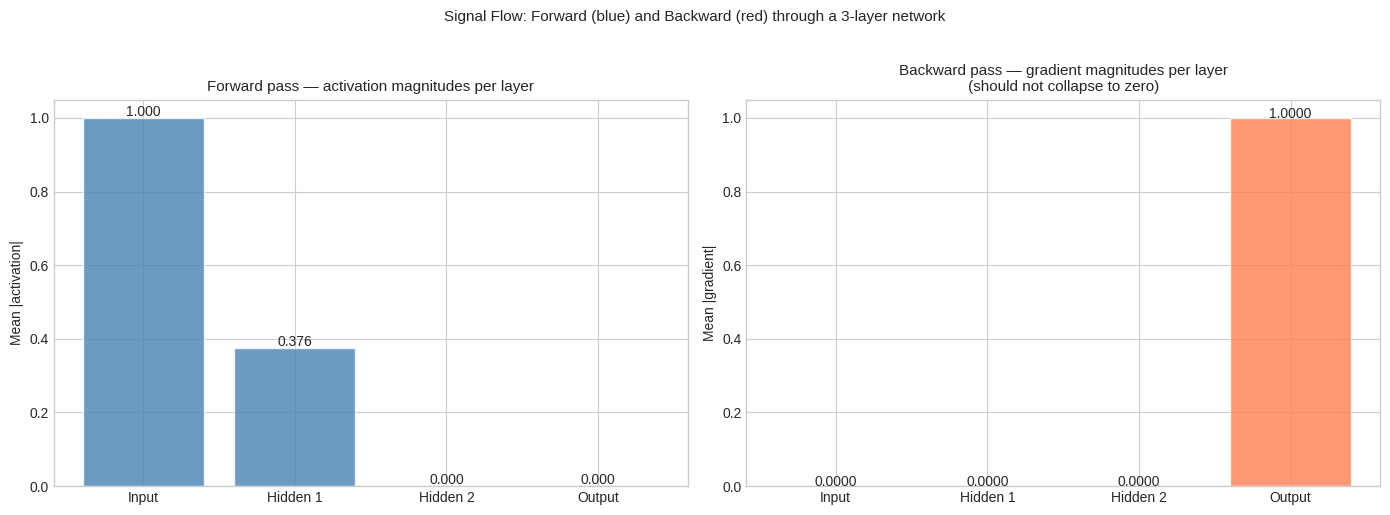

Loss: 0.500000
Output: 0.0000  Target: 1.0

If gradient magnitudes collapse toward the input layer -> vanishing gradient
If gradient magnitudes explode -> exploding gradient


In [42]:
# Visualize how gradient flows backward through a 3-layer network
np.random.seed(42)

# Simple 3-layer network: input(2) -> hidden1(4) -> hidden2(4) -> output(1)
dims = [2, 4, 4, 1]

# Random weights
Ws = [np.random.randn(dims[i+1], dims[i]) * 0.5 for i in range(3)]
bs = [np.zeros(dims[i+1]) for i in range(3)]

# One training sample
x_vis = np.array([1.5, -0.5])
y_vis = 1.0

# Forward pass
activations = [x_vis]
pre_acts    = []
for idx, (W, b) in enumerate(zip(Ws, bs)):
    z = W @ activations[-1] + b
    pre_acts.append(z)
    if idx < len(Ws) - 1:
        a = np.maximum(0, z)   # ReLU for hidden layers
    else:
        a = z                  # linear output
    activations.append(a)

output = activations[-1].item() if isinstance(activations[-1], np.ndarray) and activations[-1].size == 1 else float(activations[-1])
loss   = 0.5 * (y_vis - output)**2

# Backward pass — track gradient magnitudes per layer
# Start with scalar output gradient (as a 1D array for @ compatibility)
delta = np.array([-(y_vis - output)])   # dL/d_output (shape (1,))

grad_magnitudes = [np.mean(np.abs(delta))]  # output layer magnitude

for l in range(len(Ws)-1, -1, -1):   # layers 2,1,0
    W = Ws[l]
    # propagate through linear map
    delta = W.T @ delta               # shapes align: (in_dim, out_dim) @ (out_dim,)
    # if there is a ReLU before this weight, apply its derivative
    if l-1 >= 0:
        drelu = (pre_acts[l-1] > 0).astype(float)
        delta = delta * drelu
    grad_magnitudes.insert(0, np.mean(np.abs(delta)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Activation magnitudes (forward)
fwd_mags = [np.mean(np.abs(a)) if isinstance(a, np.ndarray) else abs(a) for a in activations]
layers   = ['Input', 'Hidden 1', 'Hidden 2', 'Output']
axes[0].bar(layers, fwd_mags, color='steelblue', alpha=0.8, edgecolor='white')
axes[0].set_title('Forward pass — activation magnitudes per layer', fontsize=11)
axes[0].set_ylabel('Mean |activation|')
for i, v in enumerate(fwd_mags):
    axes[0].text(i, v+0.005, f'{v:.3f}', ha='center', fontsize=10)

# Gradient magnitudes (backward)
axes[1].bar(layers, grad_magnitudes, color='coral', alpha=0.8, edgecolor='white')
axes[1].set_title('Backward pass — gradient magnitudes per layer\n'
                   '(should not collapse to zero)', fontsize=11)
axes[1].set_ylabel('Mean |gradient|')
for i, v in enumerate(grad_magnitudes):
    axes[1].text(i, v+0.001, f'{v:.4f}', ha='center', fontsize=10)

plt.suptitle('Signal Flow: Forward (blue) and Backward (red) through a 3-layer network',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

print(f'Loss: {loss:.6f}')
print(f'Output: {output:.4f}  Target: {y_vis}')
print('\nIf gradient magnitudes collapse toward the input layer -> vanishing gradient')
print('If gradient magnitudes explode -> exploding gradient')


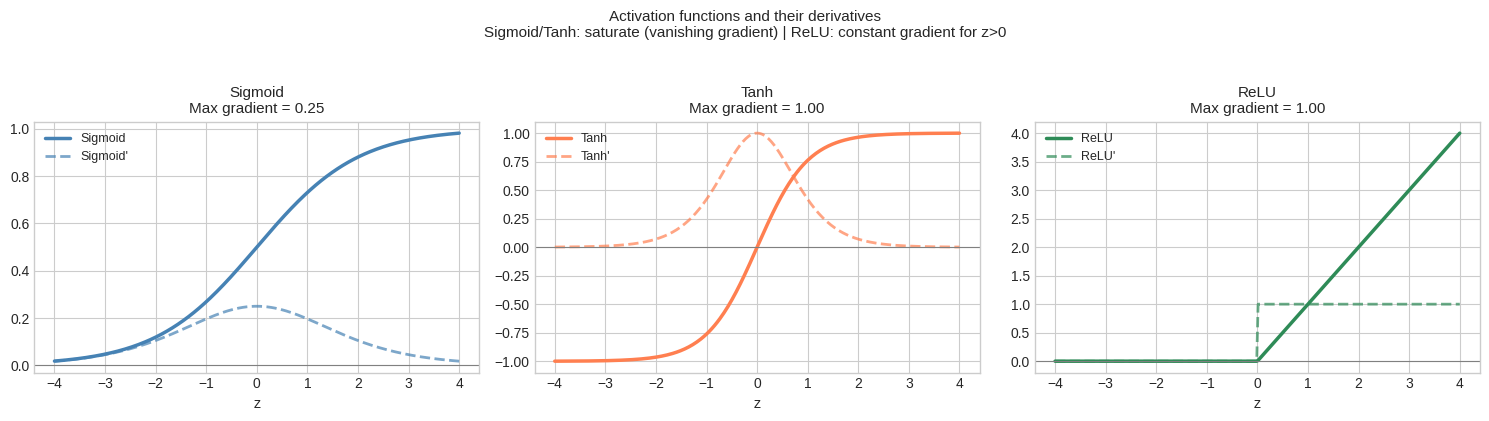

In [43]:
# Visualize effect of activation function choice on gradient flow
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
x_range = np.linspace(-4, 4, 300)

activations_dict = {
    'Sigmoid': (lambda x: 1/(1+np.exp(-x)),
                lambda x: (1/(1+np.exp(-x)))*(1-(1/(1+np.exp(-x)))),
                'steelblue'),
    'Tanh':    (lambda x: np.tanh(x),
                lambda x: 1 - np.tanh(x)**2,
                'coral'),
    'ReLU':    (lambda x: np.maximum(0, x),
                lambda x: (x > 0).astype(float),
                'seagreen'),
}

for ax, (name, (f, df, color)) in zip(axes, activations_dict.items()):
    y_act  = f(x_range)
    dy_act = df(x_range)
    ax.plot(x_range, y_act,  color=color, linewidth=2.5, label=f'{name}')
    ax.plot(x_range, dy_act, color=color, linewidth=2, linestyle='--',
            alpha=0.7, label=f"{name}'")
    ax.axhline(0, color='gray', linewidth=0.8)
    max_grad = dy_act.max()
    ax.set_title(f'{name}\nMax gradient = {max_grad:.2f}', fontsize=11)
    ax.legend(fontsize=9)
    ax.set_xlabel('z')

plt.suptitle('Activation functions and their derivatives\n'
             'Sigmoid/Tanh: saturate (vanishing gradient) | ReLU: constant gradient for z>0',
             fontsize=11, y=1.04)
plt.tight_layout()
plt.show()


## 10. Exercises

**Exercise 1:** Derive and implement the gradient of the **cross-entropy loss** with respect to the logits $z$ for a **binary classification** problem (sigmoid output):

$$L = -[y \log \hat{y} + (1-y) \log(1-\hat{y})] \quad \text{where} \quad \hat{y} = \sigma(z)$$

Show the full derivation step by step, then implement it and verify with numerical gradients.


In [44]:
# Your code here — derive dL/dz and implement it


In [45]:
# Solution
# Step 1: dL/dŷ
#   dL/dŷ = -y/ŷ + (1-y)/(1-ŷ)
# Step 2: dŷ/dz = σ(z)(1-σ(z)) = ŷ(1-ŷ)
# Step 3: chain rule
#   dL/dz = dL/dŷ * dŷ/dz
#         = [-y/ŷ + (1-y)/(1-ŷ)] * ŷ(1-ŷ)
#         = -y(1-ŷ) + (1-y)ŷ
#         = -y + yŷ + ŷ - yŷ
#         = ŷ - y   <- beautifully simple!

def binary_ce_with_logits_grad(z, y):
    y_hat = 1 / (1 + np.exp(-z))
    loss  = -(y * np.log(y_hat + 1e-12) + (1-y) * np.log(1 - y_hat + 1e-12)).mean()
    dL_dz = (y_hat - y) / len(y)    # <- chain rule result
    return loss, dL_dz, y_hat

np.random.seed(5)
z_ex1 = np.random.randn(10)
y_ex1 = np.random.randint(0, 2, 10).astype(float)

loss_ex1, dL_dz_anal, yhat_ex1 = binary_ce_with_logits_grad(z_ex1, y_ex1)

# Numerical gradient
h = 1e-5
dL_dz_num = np.zeros_like(z_ex1)
for i in range(len(z_ex1)):
    z_plus  = z_ex1.copy(); z_plus[i]  += h
    z_minus = z_ex1.copy(); z_minus[i] -= h
    loss_p, _, _ = binary_ce_with_logits_grad(z_plus, y_ex1)
    loss_m, _, _ = binary_ce_with_logits_grad(z_minus, y_ex1)
    dL_dz_num[i] = (loss_p - loss_m) / (2*h)

print('Derivation result: dL/dz = ŷ - y  (predicted minus true!)')
print()
print('Gradient verification:')
print(f'  Analytical: {dL_dz_anal[:5].round(6)}')
print(f'  Numerical:  {dL_dz_num[:5].round(6)}')
rel_err = np.linalg.norm(dL_dz_anal-dL_dz_num) / (np.linalg.norm(dL_dz_anal)+np.linalg.norm(dL_dz_num))
print(f'  Relative error: {rel_err:.2e}  ✓' if rel_err < 1e-5 else f'  Relative error: {rel_err:.2e}  FAIL')


Derivation result: dL/dz = ŷ - y  (predicted minus true!)

Gradient verification:
  Analytical: [ 0.060855 -0.058197 -0.008086 -0.056269 -0.047262]
  Numerical:  [ 0.060855 -0.058197 -0.008086 -0.056269 -0.047262]
  Relative error: 3.91e-11  ✓


**Exercise 2:** Implement the **backward pass for Layer Normalization** used in transformers:

$$\text{Forward: } \hat{x}_i = \frac{x_i - \mu}{\sqrt{\sigma^2 + \epsilon}}, \quad y_i = \gamma \hat{x}_i + \beta$$

where $\mu$ and $\sigma^2$ are computed across **features** (not batch, unlike BatchNorm). Implement forward and backward, then verify with gradient checking.


In [46]:
# Your code here


In [47]:
# Solution
def layernorm_forward(x, gamma, beta, eps=1e-5):
    # x: (batch, features) — normalize across features
    mu    = x.mean(axis=-1, keepdims=True)
    var   = x.var(axis=-1, keepdims=True)
    x_hat = (x - mu) / np.sqrt(var + eps)
    y     = gamma * x_hat + beta
    return y, (x, x_hat, mu, var, gamma, eps)

def layernorm_backward(dL_dy, cache):
    x, x_hat, mu, var, gamma, eps = cache
    N     = x.shape[-1]   # number of features
    dL_dgamma = (dL_dy * x_hat).sum(axis=0)
    dL_dbeta  = dL_dy.sum(axis=0)
    dL_dxhat  = dL_dy * gamma
    std_inv   = 1.0 / np.sqrt(var + eps)
    dL_dx     = (1.0/N) * std_inv * (
        N * dL_dxhat
        - dL_dxhat.sum(axis=-1, keepdims=True)
        - x_hat * (dL_dxhat * x_hat).sum(axis=-1, keepdims=True)
    )
    return dL_dx, dL_dgamma, dL_dbeta

np.random.seed(3)
batch, features = 4, 8
x_ln     = np.random.randn(batch, features)
gamma_ln = np.ones(features)
beta_ln  = np.zeros(features)

y_ln, cache_ln = layernorm_forward(x_ln, gamma_ln, beta_ln)
dL_dy_ln       = np.random.randn(*y_ln.shape)
dL_dx_ln, dL_dgamma_ln, dL_dbeta_ln = layernorm_backward(dL_dy_ln, cache_ln)

# Numerical check for dL/dx
dL_dx_num = np.zeros_like(x_ln)
h = 1e-5
for i in range(batch):
    for j in range(features):
        xp = x_ln.copy(); xp[i,j] += h
        xm = x_ln.copy(); xm[i,j] -= h
        yp, _ = layernorm_forward(xp, gamma_ln, beta_ln)
        ym, _ = layernorm_forward(xm, gamma_ln, beta_ln)
        dL_dx_num[i,j] = ((yp - ym) / (2*h) * dL_dy_ln).sum()

rel_err = np.linalg.norm(dL_dx_ln - dL_dx_num) / (np.linalg.norm(dL_dx_ln) + np.linalg.norm(dL_dx_num))
print(f'LayerNorm backward — relative error: {rel_err:.2e}  '
      + ('✓' if rel_err < 1e-5 else '✗'))
print(f'Output shape: {y_ln.shape}')
print(f'y mean across features ≈ 0: {y_ln.mean(axis=-1).round(4)}')
print(f'y std  across features ≈ 1: {y_ln.std(axis=-1).round(4)}')


LayerNorm backward — relative error: 7.79e-12  ✓
Output shape: (4, 8)
y mean across features ≈ 0: [ 0.  0.  0. -0.]
y std  across features ≈ 1: [1. 1. 1. 1.]


**Exercise 3:** Extend the `Value` class (our minigrad implementation) to support:
- Division: `__truediv__`
- Power: `__pow__`
- `tanh` activation

Then build and train a tiny 2-layer MLP on XOR data using **only** your `Value` class (no NumPy for the forward/backward pass). Show the loss decreasing over 500 steps.


In [48]:
# Your code here


Final predictions:
  Input [0.0, 0.0] -> pred=0.0096  true=0.0  ✓
  Input [0.0, 1.0] -> pred=0.9211  true=1.0  ✓
  Input [1.0, 0.0] -> pred=0.9059  true=1.0  ✓
  Input [1.0, 1.0] -> pred=0.0156  true=0.0  ✓


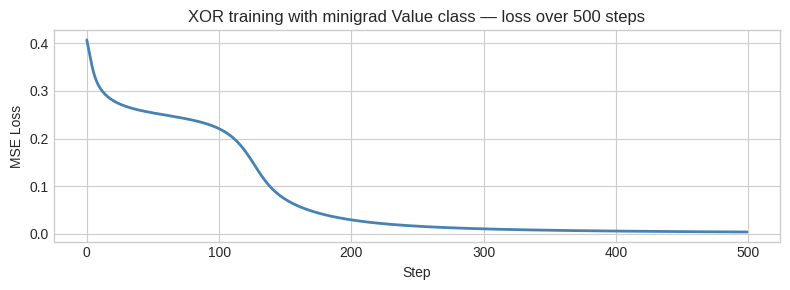

In [54]:
# Solution
class ValueV2(Value):
    def __truediv__(self, other):
        return self * other**(-1)

    def __pow__(self, exp):
        assert isinstance(exp, (int, float))
        out = ValueV2(self.data**exp, (self,), f'**{exp}')
        def _backward():
            self.grad += exp * (self.data**(exp-1)) * out.grad
        out._backward = _backward
        return out

    def tanh(self):
        t   = np.tanh(self.data)
        out = ValueV2(t, (self,), 'tanh')
        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        return out

    def __neg__(self):     return self * -1
    def __radd__(self, o): return self + o
    def __rmul__(self, o): return self * o
    def __rsub__(self, o): return ValueV2(o) + (-self)

# XOR data
XOR_X = [[0.0,0.0],[0.0,1.0],[1.0,0.0],[1.0,1.0]]
XOR_y = [0.0, 1.0, 1.0, 0.0]

# Tiny 2-layer MLP
np.random.seed(1)
def make_param(n): return [ValueV2(float(np.random.randn())) for _ in range(n)]

# Layer 1: 2 inputs -> 4 hidden
W1_v = [make_param(2) for _ in range(4)]
b1_v = make_param(4)
# Layer 2: 4 hidden -> 1 output
W2_v = make_param(4)
b2_v = make_param(1)

def forward_xor(x):
    x_v = [ValueV2(xi) for xi in x]
    # Hidden layer
    h = [sum((w*xi for w,xi in zip(W1_v[j], x_v)), ValueV2(0.0)) + b1_v[j]
         for j in range(4)]
    h = [hi.tanh() for hi in h]
    # Output
    out = sum((w*hi for w,hi in zip(W2_v, h)), ValueV2(0.0)) + b2_v[0]
    return out.tanh()

all_params = [p for row in W1_v for p in row] + b1_v + W2_v + b2_v

losses = []
lr_xor = 0.1
for step in range(500):
    # Forward + loss
    total_loss = ValueV2(0.0)
    for x, y in zip(XOR_X, XOR_y):
        pred  = forward_xor(x)
        diff  = pred + ValueV2(-y)
        total_loss = total_loss + diff**2
    total_loss = total_loss * ValueV2(0.25)
    losses.append(total_loss.data)

    # Zero grads
    for p in all_params: p.grad = 0.0

    # Backward
    total_loss.backward()

    # Update
    for p in all_params:
        p.data -= lr_xor * p.grad

print('Final predictions:')
for x, y in zip(XOR_X, XOR_y):
    pred = forward_xor(x)
    ok = '✓' if abs(pred.data - y) < 0.1 else '✗'
    print(f"  Input {x} -> pred={pred.data:.4f}  true={y}  {ok}")

fig, ax = plt.subplots(figsize=(8,3))
ax.plot(losses, color='steelblue', linewidth=2)
ax.set_title('XOR training with minigrad Value class — loss over 500 steps')
ax.set_xlabel('Step'); ax.set_ylabel('MSE Loss')
plt.tight_layout()
plt.show()


---

## 👨‍💻 Author

**Himanshu Kumar**

- 🌐 GitHub: [@himanshu231204](https://github.com/himanshu231204)
- 💼 LinkedIn: [himanshu231204](https://www.linkedin.com/in/himanshu231204)
- 🐦 Twitter/X: [@himanshu231204](https://twitter.com/himanshu231204)
- 📧 Email: himanshu231204@gmail.com
